In [1]:
import numpy as np, pandas as pd
from sklearn.datasets import make_blobs

In [2]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

2026-04-12 11:51:59.730908: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-12 11:51:59.926901: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-12 11:51:59.927031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-12 11:51:59.933069: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-12 11:51:59.966197: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-12 11:51:59.967693: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [19]:
X, y = make_blobs(n_samples=300, n_features=2, centers=2, cluster_std=2.5, random_state=2)
X_train, y_train = X[:100, :], y[:100]

In [20]:
import matplotlib.pyplot as plt
plt.style.use('default')

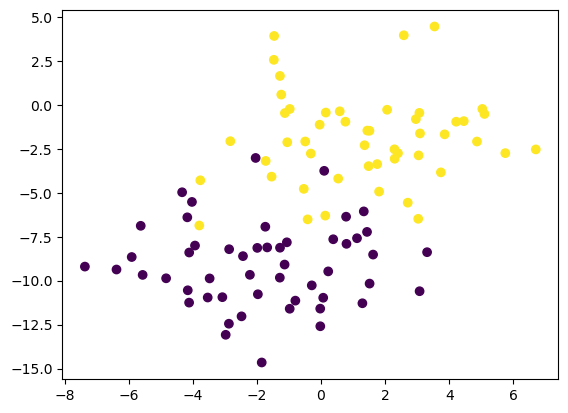

In [21]:
plt.scatter(X_train[:, 0],X_train[:, 1], c=y_train)

In [22]:
model = Sequential()

In [23]:
model.add(Input(shape= (2,)))
model.add(Dense(2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

It gives zero fitting results even with activation function 'tanh'. 

In [24]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 2)                 6         
                                                                 
 dense_3 (Dense)             (None, 1)                 3         
                                                                 
Total params: 9 (36.00 Byte)
Trainable params: 9 (36.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [25]:
model.get_weights()

[array([[-0.13653457,  0.8274981 ],
        [ 0.15537715, -0.87945235]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 1.3525809 ],
        [-0.84454864]], dtype=float32),
 array([0.], dtype=float32)]

In [26]:
initial_weights = model.get_weights()
initial_weights

[array([[-0.13653457,  0.8274981 ],
        [ 0.15537715, -0.87945235]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 1.3525809 ],
        [-0.84454864]], dtype=float32),
 array([0.], dtype=float32)]

In [27]:
print(type(initial_weights))
len(initial_weights)

<class 'list'>


4

In [28]:
initial_weights[0] = np.zeros_like(model.get_weights()[0])
initial_weights[1] = np.zeros_like(model.get_weights()[1])
initial_weights[2] = np.zeros_like(model.get_weights()[2])
initial_weights[3] = np.zeros_like(model.get_weights()[3])
model.set_weights(initial_weights)
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [29]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [30]:
model.fit(X, y, epochs=44, validation_split=0.2, verbose=1)

Epoch 1/44
8/8 [==============================] - 5s 183ms/step - loss: 0.6932 - accuracy: 0.4833 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/44
8/8 [==============================] - 0s 61ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/44
8/8 [==============================] - 0s 40ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/44
8/8 [==============================] - 0s 33ms/step - loss: 0.6932 - accuracy: 0.4750 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 5/44
8/8 [==============================] - 0s 42ms/step - loss: 0.6931 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 6/44
8/8 [==============================] - 0s 37ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 7/44
8/8 [==============================] - 0s 41ms/step - loss: 0.6932 - accuracy: 0.5000 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 8/44
8/8 [==========

In [31]:
from mlxtend.plotting import plot_decision_regions

9600/9600 [==============================] - 142s 15ms/step


<Axes: >

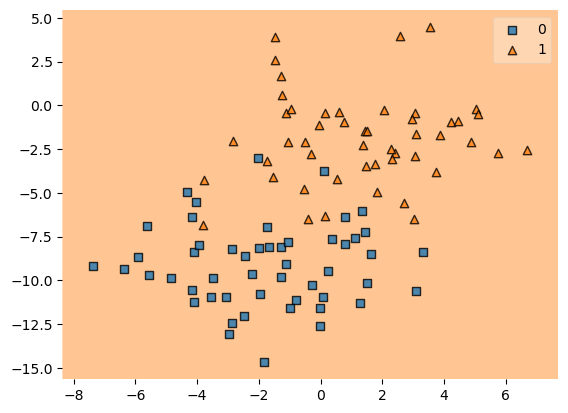

In [32]:
plot_decision_regions(X_train, y_train, clf = model)

# All the weights remain same as initializatized as zero, with relu and tanh nothing hapens in training.